In [ ]:
 
from src.schema.models import (
    SQLTableSchema, MongoCollectionSchema, CrossSourceRelation
)
from config.settings import settings
from openai import OpenAI
from dotenv import load_dotenv
import json
import re
import logging

load_dotenv()
client = OpenAI(
            base_url="https://router.huggingface.co/v1",
            api_key=settings.HF_TOKEN,
        )


response = client.chat.completions.create(
            model=settings.HF_MODEL,
            temperature=0,
            # NOTE: response_format is intentionally NOT set to json_object
            # because json_object mode forces a dict wrapper and breaks plain arrays
            messages=[
                {
                    "role": "system",
                    "content": "you are professinal database enginner",
                },
                {
                    "role": "user",
                    "content": (
                      "wrote queary to get the highest number of orders"
                    ),
                },
            ],
        )

response

AttributeError: 'ChatCompletion' object has no attribute 'content'


Question: --f=/run/user/1000/jupyter/runtime/kernel-v383786895ea9ab26a029ba30d5a82500406642f0c.json



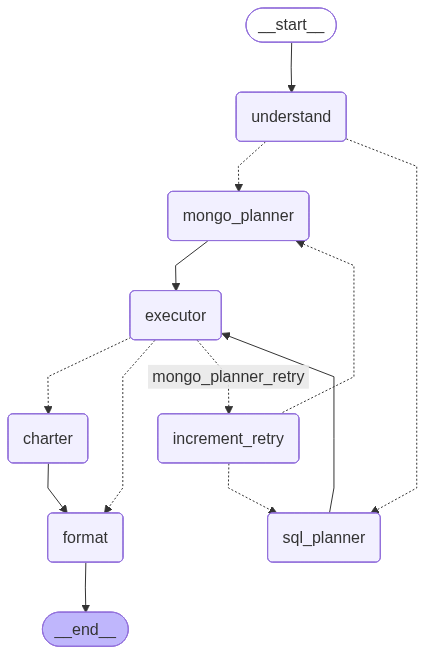

None


AttributeError: 'Settings' object has no attribute 'groq_model'

In [3]:
# src/agent/graph.py

from langgraph.graph import StateGraph, END
from src.agent.state import AgentState
from src.agent.nodes.understand_node import understand_node
from src.agent.nodes.sql_planner_node import sql_planner_node
from src.agent.nodes.mongo_planner_node import mongo_planner_node
from src.agent.nodes.executor_node import executor_node
from src.agent.nodes.format_node import format_node
from IPython.display import display ,Image

import logging

logger = logging.getLogger(__name__)


# ── Optional charter node ──────────────────────────────────────────────────
# If you have a charter_node, import it here.
# from src.agent.nodes.charter_node import charter_node
# Otherwise, we use a passthrough so the graph still compiles.

def charter_node(state: AgentState) -> AgentState:
    """
    Passthrough stub — replace with your real charter_node when ready.
    Set state["chart_spec"] = {...} here to attach a chart to the response.
    """
    return {**state, "chart_spec": None}


# ── Routing functions ──────────────────────────────────────────────────────

def route_planner(state: AgentState) -> str:
    """
    After understand_node: decide which planner to send the question to.

    source="sql"   → sql_planner
    source="mongo" → mongo_planner
    source="both"  → sql_planner (runs first; mongo follows in a second pass
                     — extend this if you need true cross-source joins)
    """
    source = state.get("source", "sql")
    logger.info(f"[router] route_planner: source={source}")

    if source == "mongo":
        return "mongo_planner"
    return "sql_planner"   # default covers "sql" and "both"


def route_after_exec(state: AgentState) -> str:
    """
    After executor_node: decide what happens next.

    - Success                      → charter  (then format)
    - Failure + retries remaining  → back to the right planner
    - Failure + no retries left    → format   (with final_error set)
    """
    success     = state.get("success", False)
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 2)
    query_type  = state.get("query_type", "sql")

    if success:
        logger.info("[router] route_after_exec: success → charter")

        # Decide whether to go to charter (needs_chart=True) or straight to format
        if state.get("needs_chart"):
            return "charter"
        return "format"

    if retry_count < max_retries:
        logger.info(
            f"[router] route_after_exec: failed, retry {retry_count + 1}/{max_retries} "
            f"→ {query_type}_planner"
        )
        # Copy execution error into error_feedback for the planner prompt
        # and increment the retry counter
        return f"{query_type}_planner_retry"

    # All retries exhausted
    logger.warning("[router] route_after_exec: max retries hit → format")
    return "format"


def increment_retry(state: AgentState) -> AgentState:
    """
    Tiny node that bumps retry_count and copies execution_error
    into error_feedback before handing off to the planner again.
    """
    return {
        **state,
        "retry_count":  state.get("retry_count", 0) + 1,
        "error_feedback": state.get("execution_error"),
    }


def set_final_error(state: AgentState) -> AgentState:
    """
    Called when all retries are exhausted before format_node runs,
    so format_node can report a meaningful failure message.
    """
    return {
        **state,
        "final_error": (
            f"Could not generate a valid query after "
            f"{state.get('max_retries', 2)} attempt(s). "
            f"Last error: {state.get('execution_error', 'unknown')}"
        ),
    }


# ── Graph builder ──────────────────────────────────────────────────────────

def build_graph() -> StateGraph:
    """
    Assembles and compiles the full BI agent graph.

    Nodes
    ─────
      understand        → classify intent, source, entities
      sql_planner       → write SQL SELECT
      mongo_planner     → write Mongo aggregation pipeline
      executor          → run the query
      increment_retry   → bump counter + copy error into feedback
      charter           → optionally produce a chart spec
      format            → write the plain-English answer

    Edges
    ─────
      START → understand
      understand → [sql_planner | mongo_planner]   (route_planner)
      sql_planner / mongo_planner → executor
      executor → [charter | sql_planner_retry | mongo_planner_retry | format]
                                                    (route_after_exec)
      sql_planner_retry   → sql_planner
      mongo_planner_retry → mongo_planner
      charter → format
      format → END
    """
    graph = StateGraph(AgentState)

    # ── Add nodes ──────────────────────────────────────────────────────
    graph.add_node("understand",        understand_node)
    graph.add_node("sql_planner",       sql_planner_node)
    graph.add_node("mongo_planner",     mongo_planner_node)
    graph.add_node("executor",          executor_node)
    graph.add_node("increment_retry",   increment_retry)
    graph.add_node("charter",           charter_node)
    graph.add_node("format",            format_node)

    # ── Entry point ────────────────────────────────────────────────────
    graph.set_entry_point("understand")

    # ── understand → planner (conditional) ────────────────────────────
    graph.add_conditional_edges(
        "understand",
        route_planner,
        {
            "sql_planner":   "sql_planner",
            "mongo_planner": "mongo_planner",
        },
    )

    # ── Both planners feed into executor ──────────────────────────────
    graph.add_edge("sql_planner",   "executor")
    graph.add_edge("mongo_planner", "executor")

    # ── executor → charter | retry | format (conditional) ─────────────
    graph.add_conditional_edges(
        "executor",
        route_after_exec,
        {
            "charter":             "charter",
            "format":              "format",
            "sql_planner_retry":   "increment_retry",
            "mongo_planner_retry": "increment_retry",
        },
    )

    # ── Retry loop: increment → correct planner ────────────────────────
    # We re-use increment_retry for both SQL and Mongo retries.
    # The planner reads state.query_type to know what it generated last time,
    # and state.error_feedback to know what went wrong.
    graph.add_conditional_edges(
        "increment_retry",
        lambda s: "sql_planner" if s.get("query_type") == "sql" else "mongo_planner",
        {
            "sql_planner":   "sql_planner",
            "mongo_planner": "mongo_planner",
        },
    )

    # ── charter → format → END ─────────────────────────────────────────
    graph.add_edge("charter", "format")
    graph.add_edge("format",  END)

    return graph.compile()


# ── Default initial state ──────────────────────────────────────────────────

def initial_state(question: str) -> AgentState:
    """
    Returns a clean AgentState seeded with the user's question.
    Pass this into graph.invoke() every time.
    """
    return {
        # Input
        "question": question,

        # Understand (filled by understand_node)
        "intent":           "",
        "source":           "sql",
        "entities":         [],
        "needs_chart":      False,
        "intent_reasoning": "",

        # Planner (filled by sql_planner_node / mongo_planner_node)
        "query_type":      "sql",
        "query":           "",
        "collection":      None,
        "query_reasoning": "",

        # Executor (filled by executor_node)
        "success":          False,
        "data":             [],
        "row_count":        0,
        "execution_error":  None,

        # Retry control
        "retry_count":    0,
        "max_retries":    2,
        "error_feedback": None,

        # Format (filled by format_node)
        "response":    None,
        "final_error": None,

        # Charter (filled by charter_node)
        "chart_spec": None,
    }


# ── Convenience runner ─────────────────────────────────────────────────────

def run(question: str) -> AgentState:
    """
    One-liner to run the full agent pipeline.

    Usage:
        from src.agent.graph import run
        result = run("How many orders did Alice place?")
        print(result["response"])
        if result["chart_spec"]:
            print(result["chart_spec"])
    """
    app   = build_graph()
    print(display(Image(app.get_graph().draw_mermaid_png())))
    state = initial_state(question)

    print(app)
    return app.invoke(state)


# ── CLI entrypoint ─────────────────────────────────────────────────────────

if __name__ == "__main__":
    import sys

    question = " ".join(sys.argv[1:]) or "How many orders are in the database?"
    print(f"\nQuestion: {question}\n")

    result = run(question)

    print(f"Response: {result.get('response')}")
    if result.get("chart_spec"):
        import json
        print(f"\nChart spec:\n{json.dumps(result['chart_spec'], indent=2)}")
    if result.get("final_error"):
        print(f"\nError: {result['final_error']}")


Question: --f=/run/user/1000/jupyter/runtime/kernel-v383786895ea9ab26a029ba30d5a82500406642f0c.json



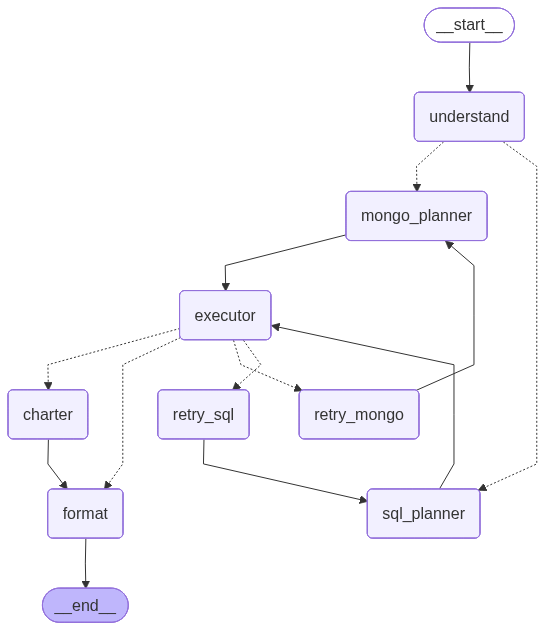

None


AttributeError: 'Settings' object has no attribute 'groq_model'

In [ ]:
# src/agent/graph.py

import sys
from pathlib import Patha

from langgraph.graph import StateGraph, END
from src.agent.state import AgentState
from src.agent.nodes.understand_node import understand_node
from src.agent.nodes.sql_planner_node import sql_planner_node
from src.agent.nodes.mongo_planner_node import mongo_planner_node
from src.agent.nodes.executor_node import executor_node
from src.agent.nodes.format_node import format_node
import logging

logger = logging.getLogger(__name__)


# ── Optional charter node ──────────────────────────────────────────────────
# from src.agent.nodes.charter_node import charter_node

def charter_node(state: AgentState) -> AgentState:
    """Passthrough stub — replace with your real charter_node when ready."""
    return {**state, "chart_spec": None}


# ── Retry nodes (one per planner) ─────────────────────────────────────────
# Having two separate nodes makes the graph topology explicit —
# LangGraph draws both retry arrows correctly instead of collapsing them.

def retry_sql(state: AgentState) -> AgentState:
    """Bumps retry_count and copies the error before going back to sql_planner."""
    logger.info(f"[retry_sql] retry {state.get('retry_count', 0) + 1}")
    return {
        **state,
        "retry_count":    state.get("retry_count", 0) + 1,
        "error_feedback": state.get("execution_error"),
    }


def retry_mongo(state: AgentState) -> AgentState:
    """Bumps retry_count and copies the error before going back to mongo_planner."""
    logger.info(f"[retry_mongo] retry {state.get('retry_count', 0) + 1}")
    return {
        **state,
        "retry_count":    state.get("retry_count", 0) + 1,
        "error_feedback": state.get("execution_error"),
    }


# ── Routing functions ──────────────────────────────────────────────────────

def route_planner(state: AgentState) -> str:
    """
    After understand_node — pick the right planner.
    source="sql"   → sql_planner
    source="mongo" → mongo_planner
    source="both"  → sql_planner (extend later for true cross-source joins)
    """
    source = state.get("source", "sql")
    logger.info(f"[router] route_planner: source={source}")
    return "mongo_planner" if source == "mongo" else "sql_planner"


def route_after_exec(state: AgentState) -> str:
    """
    After executor_node — four possible outcomes:
      success + needs_chart        → charter
      success + no chart           → format
      failure + retries remaining  → retry_sql  OR  retry_mongo
      failure + no retries left    → format  (final_error set by format_node)
    """
    success     = state.get("success", False)
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 2)
    query_type  = state.get("query_type", "sql")

    if success:
        route = "charter" if state.get("needs_chart") else "format"
        logger.info(f"[router] route_after_exec: success → {route}")
        return route

    if retry_count < max_retries:
        route = "retry_sql" if query_type == "sql" else "retry_mongo"
        logger.info(
            f"[router] route_after_exec: failed "
            f"({retry_count + 1}/{max_retries}) → {route}"
        )
        return route

    logger.warning("[router] route_after_exec: max retries exhausted → format")
    return "format"


# ── Graph builder ──────────────────────────────────────────────────────────

def build_graph() -> StateGraph:
    """
    Nodes
    ─────
      understand    → classify intent, source, entities, needs_chart
      sql_planner   → write SQL SELECT
      mongo_planner → write Mongo aggregation pipeline
      executor      → run the query against the real DB
      retry_sql     → bump counter + copy error, then back to sql_planner
      retry_mongo   → bump counter + copy error, then back to mongo_planner
      charter       → optionally produce a chart spec
      format        → write the plain-English answer

    Edges
    ─────
      START → understand
      understand  → sql_planner | mongo_planner        (route_planner)
      sql_planner   → executor
      mongo_planner → executor
      executor    → charter | format | retry_sql | retry_mongo  (route_after_exec)
      retry_sql   → sql_planner
      retry_mongo → mongo_planner
      charter     → format
      format      → END
    """
    graph = StateGraph(AgentState)

    # ── Nodes ──────────────────────────────────────────────────────────
    graph.add_node("understand",    understand_node)
    graph.add_node("sql_planner",   sql_planner_node)
    graph.add_node("mongo_planner", mongo_planner_node)
    graph.add_node("executor",      executor_node)
    graph.add_node("retry_sql",     retry_sql)
    graph.add_node("retry_mongo",   retry_mongo)
    graph.add_node("charter",       charter_node)
    graph.add_node("format",        format_node)

    # ── Entry ──────────────────────────────────────────────────────────
    graph.set_entry_point("understand")

    # ── understand → planner ───────────────────────────────────────────
    graph.add_conditional_edges(
        "understand",
        route_planner,
        {
            "sql_planner":   "sql_planner",
            "mongo_planner": "mongo_planner",
        },
    )

    # ── planners → executor ────────────────────────────────────────────
    graph.add_edge("sql_planner",   "executor")
    graph.add_edge("mongo_planner", "executor")

    # ── executor → charter | format | retry_sql | retry_mongo ──────────
    graph.add_conditional_edges(
        "executor",
        route_after_exec,
        {
            "charter":     "charter",
            "format":      "format",
            "retry_sql":   "retry_sql",
            "retry_mongo": "retry_mongo",
        },
    )

    # ── retry loops back to the correct planner ────────────────────────
    graph.add_edge("retry_sql",   "sql_planner")
    graph.add_edge("retry_mongo", "mongo_planner")

    # ── charter → format → END ─────────────────────────────────────────
    graph.add_edge("charter", "format")
    graph.add_edge("format",  END)

    return graph.compile()


# ── Default initial state ──────────────────────────────────────────────────

def initial_state(question: str) -> AgentState:
    return {
        "question":         question,
        "intent":           "",
        "source":           "sql",
        "entities":         [],
        "needs_chart":      False,
        "intent_reasoning": "",
        "query_type":       "sql",
        "query":            "",
        "collection":       None,
        "query_reasoning":  "",
        "success":          False,
        "data":             [],
        "row_count":        0,
        "execution_error":  None,
        "retry_count":      0,
        "max_retries":      2,
        "error_feedback":   None,
        "response":         None,
        "final_error":      None,
        "chart_spec":       None,
    }


# ── Convenience runner ─────────────────────────────────────────────────────

def run(question: str) -> AgentState:
    """
    from src.agent.graph import run
    result = run("How many orders did Alice place?")
    print(result["response"])
    """
    app   = build_graph()
    print(display(Image(app.get_graph().draw_mermaid_png())))

    state = initial_state(question)
    return app.invoke(state)


# ── CLI ────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import json

    question = " ".join(sys.argv[1:]) or "How many orders are in the database?"
    print(f"\nQuestion: {question}\n")

    result = run(question)

    print(f"Response:  {result.get('response')}")
    if result.get("chart_spec"):
        print(f"Chart:     {json.dumps(result['chart_spec'], indent=2)}")
    if result.get("final_error"):
        print(f"Error:     {result['final_error']}")